# Battery Anomaly Detection - EDA

**Li-ion Battery Degradation Anomaly Detection Using Deep Learning**

Author: Eunsoo Suk | UMD Applied ML | CALCE Collaboration

---

## Notebook Goals
1. Load and validate Dataset 1 (xlsx) and Dataset 2 (mat)
2. Understand data structure, dimensions, and missing values
3. Visualize capacity fade curves (qualified vs. subsequent)
4. Identify anomalous cells visually
5. Compute basic statistics and degradation patterns
6. Validate design-document assumptions against the real data


## 0. Setup & Google Drive Mount

In [2]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Verify dataset paths
import os

DATASET1_DIR = '/content/drive/MyDrive/Dataset1'
DATASET2_DIR = '/content/drive/MyDrive/Dataset2'

print('=== Dataset1 ===')
for f in os.listdir(DATASET1_DIR):
 fpath = os.path.join(DATASET1_DIR, f)
 size_kb = os.path.getsize(fpath) / 1024
 print(f' {f} ({size_kb:.1f} KB)')

print('\n=== Dataset2 ===')
for f in os.listdir(DATASET2_DIR):
 fpath = os.path.join(DATASET2_DIR, f)
 size_kb = os.path.getsize(fpath) / 1024
 print(f' {f} ({size_kb:.1f} KB)')

Mounted at /content/drive
=== Dataset1 ===
  Qualified lots.xlsx (48.3 KB)
  Subsequent lots for ongoing reliability testing.xlsx (49.7 KB)

=== Dataset2 ===
  Dataset2.mat (29.1 KB)
  Notes.txt (0.1 KB)


In [3]:
import numpy as np
import pandas as pd
import scipy.io as sio
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 12
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print('Libraries loaded.')

Libraries loaded.


---
## 1. Dataset 1 - Load and Inspect

**Source:** CALCE Battery Anomaly Detection Dataset  
**Chemistry:** LiCoO2 (LCO), ~3260 mAh nominal  
**Format:** `.xlsx` - normalized capacity fade curves  
**Structure:** each column = 1 cell, each row = 1 cycle


In [4]:
# --- Load Dataset 1 ---

# Qualified lots (normal batteries)
d1_qual_path = os.path.join(DATASET1_DIR, 'Qualified lots.xlsx')
d1_qual_raw = pd.read_excel(d1_qual_path, sheet_name='Sheet1', header=None)

# Subsequent lots (potentially anomalous)
d1_subseq_path = os.path.join(DATASET1_DIR,
 'Subsequent lots for ongoing reliability testing.xlsx')
d1_subseq_raw = pd.read_excel(d1_subseq_path, sheet_name='Sheet1', header=None)
d1_subseq_sheet2 = pd.read_excel(d1_subseq_path, sheet_name='Sheet2', header=None)

# Rename columns
d1_qual_raw.columns = [f'D1_Qual_{i+1}' for i in range(d1_qual_raw.shape[1])]
d1_subseq_raw.columns = [f'D1_Subseq_{i+1}' for i in range(d1_subseq_raw.shape[1])]

# Add cycle index (1-based)
d1_qual_raw.index = range(1, len(d1_qual_raw) + 1)
d1_qual_raw.index.name = 'cycle'
d1_subseq_raw.index = range(1, len(d1_subseq_raw) + 1)
d1_subseq_raw.index.name = 'cycle'

print('=== Dataset 1: Qualified Lots ===')
print(f'Shape: {d1_qual_raw.shape} (cycles × cells)')
print(f'Cycle range: 1 ~ {len(d1_qual_raw)}')
print(f'\nFirst 5 rows:')
display(d1_qual_raw.head())
print(f'\nLast 5 rows:')
display(d1_qual_raw.tail())
print(f'\nBasic stats:')
display(d1_qual_raw.describe())

=== Dataset 1: Qualified Lots ===
Shape: (496, 6) (cycles × cells)
Cycle range: 1 ~ 496

First 5 rows:


,D1_Qual_1,D1_Qual_2,D1_Qual_3,D1_Qual_4,D1_Qual_5,D1_Qual_6
cycle,,,,,,
1,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
2,1.000425,0.999870,1.000096,1.000345,1.000016,1.001779
3,0.999683,0.999112,0.999612,0.999963,0.999235,1.002840
4,0.998722,0.998444,0.998646,0.999516,0.998647,1.003508
5,0.998003,0.997506,0.997891,0.998434,0.997704,1.003432



Last 5 rows:


,D1_Qual_1,D1_Qual_2,D1_Qual_3,D1_Qual_4,D1_Qual_5,D1_Qual_6
cycle,,,,,,
492,0.873978,0.886735,0.897762,0.857988,0.871832,0.891953
493,0.874048,0.886249,0.897322,0.857039,0.871522,0.891731
494,0.873322,0.886303,0.897168,0.856689,0.870891,0.891216
495,0.873158,0.885675,0.896569,0.856661,0.870281,0.891011
496,0.875418,0.886700,0.897942,0.856528,0.871367,0.890643



Basic stats:


,D1_Qual_1,D1_Qual_2,D1_Qual_3,D1_Qual_4,D1_Qual_5,D1_Qual_6
count,496.000000,496.000000,496.000000,496.000000,496.000000,496.000000
mean,0.937237,0.943281,0.944733,0.933417,0.936909,0.955263
std,0.033737,0.030005,0.028182,0.038254,0.035277,0.033991
min,0.858474,0.885675,0.882136,0.856528,0.852214,0.870033
25%,0.910553,0.920043,0.921305,0.904635,0.909200,0.928454
50%,0.939571,0.945547,0.944848,0.938279,0.940266,0.960008
75%,0.964712,0.967588,0.968627,0.965288,0.967186,0.985819
max,1.000425,1.000000,1.000096,1.000345,1.000016,1.004679


In [5]:
print('=== Dataset 1: Subsequent Lots ===')
print(f'Shape: {d1_subseq_raw.shape} (cycles × cells)')
print(f'Cycle range: 1 ~ {len(d1_subseq_raw)}')
print(f'\nFirst 5 rows:')
display(d1_subseq_raw.head())
print(f'\nLast 5 rows:')
display(d1_subseq_raw.tail())
print(f'\nBasic stats:')
display(d1_subseq_raw.describe())

=== Dataset 1: Subsequent Lots ===
Shape: (500, 6) (cycles × cells)
Cycle range: 1 ~ 500

First 5 rows:


,D1_Subseq_1,D1_Subseq_2,D1_Subseq_3,D1_Subseq_4,D1_Subseq_5,D1_Subseq_6
cycle,,,,,,
1,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
2,0.999216,0.999243,0.999315,0.999383,0.999559,0.999657
3,0.998092,0.998141,0.998152,0.998389,0.998745,0.998661
4,0.997206,0.997109,0.997228,0.997635,0.998101,0.997803
5,0.996253,0.996283,0.996440,0.996744,0.997694,0.997082



Last 5 rows:


,D1_Subseq_1,D1_Subseq_2,D1_Subseq_3,D1_Subseq_4,D1_Subseq_5,D1_Subseq_6
cycle,,,,,,
496,0.640988,0.683074,0.753132,0.783019,0.820763,0.820435
497,0.639150,0.674968,0.752840,0.782474,0.821649,0.820356
498,0.627647,0.670437,0.751267,0.781404,0.821572,0.821097
499,0.623800,0.668640,0.750509,0.780764,0.825902,0.825720
500,0.620841,0.668191,0.750393,0.780509,0.826056,0.825871



Basic stats:


,D1_Subseq_1,D1_Subseq_2,D1_Subseq_3,D1_Subseq_4,D1_Subseq_5,D1_Subseq_6
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,0.866287,0.882219,0.905700,0.914472,0.927250,0.922801
std,0.109849,0.094727,0.069407,0.060696,0.051935,0.051385
min,0.620841,0.664011,0.750393,0.780509,0.820763,0.820356
25%,0.793206,0.819666,0.860588,0.875035,0.891182,0.885851
50%,0.907961,0.922417,0.930129,0.937286,0.945942,0.939840
75%,0.960683,0.961678,0.963795,0.965266,0.971112,0.966236
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [6]:
print('=== Dataset 1: Subsequent Lots - Sheet2 (Metadata) ===')
print(f'Shape: {d1_subseq_sheet2.shape}')
print(f'\nValues:')
display(d1_subseq_sheet2)
print('\nInterpretation candidates:')
print('  H1: Anomaly-detection cycle numbers from Diao 2020 baseline')
print('  H2: Per-method results (5 rows = 5 baseline methods)')


=== Dataset 1: Subsequent Lots — Sheet2 (Metadata) ===
Shape: (5, 6)

Values:


,0,1,2,3,4,5
0,115,55,139,226,338,277
1,110,57,120,153,323,265
2,108,56,121,196,322,268
3,109,36,120,212,321,273
4,107,49,119,207,318,269



→ 이 값들이 무엇인지 확인 필요:
  가설 1: Diao 2020 baseline에서 anomaly를 감지한 cycle 번호
  가설 2: 각 baseline method별 결과 (5행 = 5가지 method?)


---
## 2. Dataset 2 - Load and Inspect

**Chemistry:** LiCoO2 (LCO), 350 mAh  
**Format:** `.mat` (MATLAB v5)  
**Structure:** 14 qualified cells + 9 subsequent cells, ~300 cycles each


In [7]:
# --- Load Dataset 2 ---
mat_path = os.path.join(DATASET2_DIR, 'Dataset2.mat')
mat_data = sio.loadmat(mat_path, squeeze_me=True)

# Extract Lot1 array
lot1 = mat_data['Lot1'] # shape=(23,), each element is (n_cycles, 2)
print(f'Top-level keys: {[k for k in mat_data.keys() if not k.startswith("__")]}')
print(f'Lot1 shape: {lot1.shape} (23 cells total)')
print(f' Cell 1-14: Qualified (normal)')
print(f' Cell 15-23: Subsequent (potentially anomalous)')

# Convert to DataFrames
d2_cells = {}
print(f'\n{"Cell":>6} {"Group":>12} {"Cycles":>8} {"Cap_start":>10} {"Cap_end":>10} {"Fade%":>8}')
print('-' * 60)
for i in range(23):
 cell_data = lot1[i]
 cell_id = i + 1
 group = 'Qualified' if cell_id <= 14 else 'Subsequent'
 cycles = cell_data[:, 0]
 capacity = cell_data[:, 1]
 fade_pct = (1 - capacity[-1]) * 100

 label = f'D2_Cell_{cell_id}'
 d2_cells[label] = pd.Series(capacity, index=cycles.astype(int), name=label)

 print(f'{cell_id:>6} {group:>12} {len(cycles):>8} {capacity[0]:>10.4f} {capacity[-1]:>10.4f} {fade_pct:>7.2f}%')

Top-level keys: ['Lot1']
Lot1 shape: (23,) (23 cells total)
  Cell 1-14: Qualified (normal)
  Cell 15-23: Subsequent (potentially anomalous)

  Cell        Group   Cycles  Cap_start    Cap_end    Fade%
------------------------------------------------------------
     1    Qualified      250     1.0027     0.9480    5.20%
     2    Qualified      250     0.9960     0.9286    7.14%
     3    Qualified      250     1.0200     0.9651    3.49%
     4    Qualified      250     0.9927     0.9202    7.98%
     5    Qualified      250     1.0133     0.9435    5.65%
     6    Qualified      250     1.0142     0.9421    5.79%
     7    Qualified      250     1.0032     0.9297    7.03%
     8    Qualified      250     1.0039     0.9276    7.24%
     9    Qualified      250     1.0043     0.9363    6.37%
    10    Qualified      250     1.0010     0.9300    7.00%
    11    Qualified      250     1.0046     0.9361    6.39%
    12    Qualified      250     1.0050     0.9316    6.84%
    13    Qualifi

In [8]:
# Combine Dataset 2 into a DataFrame
d2_qual = pd.DataFrame({k: v for k, v in d2_cells.items() if int(k.split('_')[-1]) <= 14})
d2_subseq = pd.DataFrame({k: v for k, v in d2_cells.items() if int(k.split('_')[-1]) > 14})

print(f'Dataset 2 Qualified: {d2_qual.shape}')
print(f'Dataset 2 Subsequent: {d2_subseq.shape}')
print(f'\nQualified stats:')
display(d2_qual.describe())
print(f'\nSubsequent stats:')
display(d2_subseq.describe())

Dataset 2 Qualified: (250, 14)
Dataset 2 Subsequent: (250, 9)

Qualified stats:


,D2_Cell_1,D2_Cell_2,D2_Cell_3,D2_Cell_4,D2_Cell_5,D2_Cell_6,D2_Cell_7,D2_Cell_8,D2_Cell_9,D2_Cell_10,D2_Cell_11,D2_Cell_12,D2_Cell_13,D2_Cell_14
count,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000
mean,0.964313,0.948380,0.980841,0.938324,0.961128,0.959906,0.948088,0.946847,0.955215,0.948792,0.954673,0.951293,0.959623,0.955341
std,0.011844,0.014732,0.012092,0.015494,0.014551,0.015076,0.015342,0.016267,0.014593,0.015044,0.014955,0.015785,0.012876,0.014833
min,0.947991,0.928586,0.965132,0.920178,0.943464,0.942105,0.929686,0.927616,0.936284,0.930009,0.936090,0.931562,0.944046,0.937642
25%,0.955122,0.936607,0.970986,0.926404,0.949706,0.948476,0.936769,0.933988,0.943868,0.937222,0.943237,0.938920,0.950013,0.944385
50%,0.961866,0.945501,0.978295,0.934149,0.957791,0.956077,0.943852,0.942817,0.952034,0.945275,0.950643,0.947797,0.956368,0.951387
75%,0.971245,0.956756,0.988030,0.945501,0.968302,0.966669,0.955009,0.955074,0.963143,0.956497,0.962658,0.959376,0.965375,0.962141
max,1.002713,0.995986,1.020048,0.992687,1.013256,1.014227,1.003230,1.003942,1.004330,1.000966,1.004589,1.004977,1.005559,1.008534



Subsequent stats:


,D2_Cell_15,D2_Cell_16,D2_Cell_17,D2_Cell_18,D2_Cell_19,D2_Cell_20,D2_Cell_21,D2_Cell_22,D2_Cell_23
count,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000
mean,0.926063,0.928965,0.916058,0.931468,0.911451,0.892183,0.909342,0.936031,0.928913
std,0.023976,0.022637,0.025704,0.027398,0.026927,0.031281,0.027780,0.020739,0.023339
min,0.895404,0.899027,0.883114,0.896245,0.877358,0.856659,0.875352,0.908988,0.899350
25%,0.906691,0.910863,0.895145,0.909133,0.889469,0.867752,0.887707,0.919677,0.910233
50%,0.920695,0.924285,0.910605,0.924900,0.905204,0.882824,0.902196,0.931530,0.923574
75%,0.940326,0.942332,0.931287,0.948768,0.927939,0.908793,0.924350,0.947911,0.941604
max,0.998509,0.997344,0.995080,1.006076,0.991782,0.991588,0.996503,1.001613,1.002325


---
## 3. Missing Values & Data Quality Check

In [9]:
print('=== Missing Values ===')
print(f'\nDataset 1 - Qualified: {d1_qual_raw.isna().sum().sum()} NaNs')
print(f'Dataset 1 - Subsequent: {d1_subseq_raw.isna().sum().sum()} NaNs')
print(f'Dataset 2 - Qualified: {d2_qual.isna().sum().sum()} NaNs')
print(f'Dataset 2 - Subsequent: {d2_subseq.isna().sum().sum()} NaNs')

# Check for non-monotonic capacity (noise or recovery)
print('\n=== Monotonicity Check (capacity should generally decrease) ===')
for name, df in [('D1_Qual', d1_qual_raw), ('D1_Subseq', d1_subseq_raw)]:
 for col in df.columns:
 increases = (df[col].diff() > 0).sum()
 total = len(df[col]) - 1
 pct = increases / total * 100
 print(f' {col}: {increases}/{total} cycles with capacity increase ({pct:.1f}%)')

print()
for cell_id in range(1, 24):
 label = f'D2_Cell_{cell_id}'
 s = d2_cells[label].dropna()
 increases = (s.diff() > 0).sum()
 total = len(s) - 1
 pct = increases / total * 100 if total > 0 else 0
 group = 'Qual' if cell_id <= 14 else 'Subseq'
 print(f' D2_Cell_{cell_id} ({group}): {increases}/{total} increases ({pct:.1f}%)')

=== Missing Values ===

Dataset 1 - Qualified:   0 NaNs
Dataset 1 - Subsequent:  0 NaNs
Dataset 2 - Qualified:   0 NaNs
Dataset 2 - Subsequent:  0 NaNs

=== Monotonicity Check (capacity should generally decrease) ===
  D1_Qual_1: 130/495 cycles with capacity increase (26.3%)
  D1_Qual_2: 122/495 cycles with capacity increase (24.6%)
  D1_Qual_3: 144/495 cycles with capacity increase (29.1%)
  D1_Qual_4: 114/495 cycles with capacity increase (23.0%)
  D1_Qual_5: 132/495 cycles with capacity increase (26.7%)
  D1_Qual_6: 132/495 cycles with capacity increase (26.7%)
  D1_Subseq_1: 116/499 cycles with capacity increase (23.2%)
  D1_Subseq_2: 121/499 cycles with capacity increase (24.2%)
  D1_Subseq_3: 110/499 cycles with capacity increase (22.0%)
  D1_Subseq_4: 122/499 cycles with capacity increase (24.4%)
  D1_Subseq_5: 139/499 cycles with capacity increase (27.9%)
  D1_Subseq_6: 130/499 cycles with capacity increase (26.1%)

  D2_Cell_1 (Qual): 18/249 increases (7.2%)
  D2_Cell_2 (Qual)

---
## 4. Capacity Fade Visualization

### 4.1 Dataset 1 — Qualified vs Subsequent

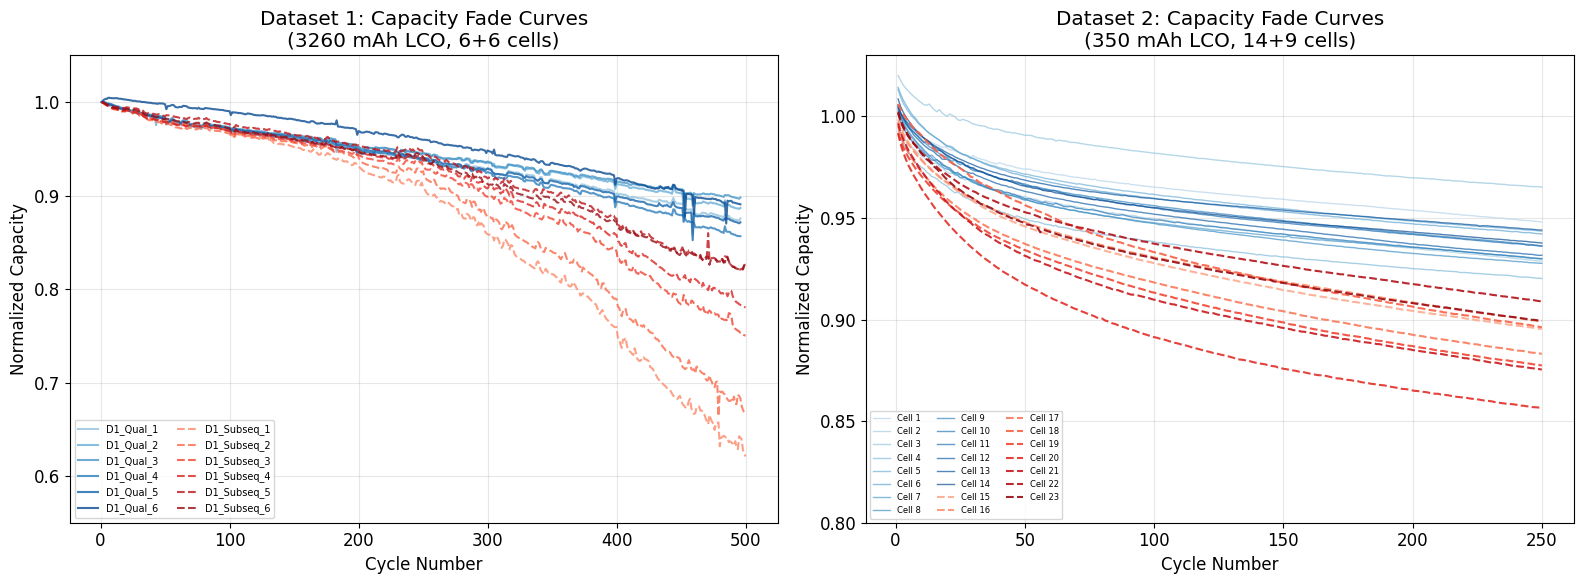

✓ Saved: fig01_capacity_fade_overview.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Dataset 1 ---
ax = axes[0]
# Qualified (blue shades)
colors_qual = cm.Blues(np.linspace(0.4, 0.9, len(d1_qual_raw.columns)))
for i, col in enumerate(d1_qual_raw.columns):
    ax.plot(d1_qual_raw.index, d1_qual_raw[col], color=colors_qual[i], alpha=0.8, linewidth=1.2, label=col if i == 0 else None)
# Subsequent (red shades)
colors_sub = cm.Reds(np.linspace(0.4, 0.9, len(d1_subseq_raw.columns)))
for i, col in enumerate(d1_subseq_raw.columns):
    ax.plot(d1_subseq_raw.index, d1_subseq_raw[col], color=colors_sub[i], alpha=0.8, linewidth=1.2, label=col if i == 0 else None)

ax.axhline(0.8, color='gray', linestyle='--', alpha=0.5, label='EOL threshold (0.8)')
ax.set_xlabel('Cycle')
ax.set_ylabel('Normalized Capacity')
ax.set_title('Dataset 1: Capacity Fade (Qualified vs. Subsequent)')
ax.legend(loc='lower left', fontsize=9)
ax.grid(True, alpha=0.3)

# --- Dataset 2 ---
ax = axes[1]
colors_qual2 = cm.Blues(np.linspace(0.3, 0.9, 14))
for i in range(1, 15):
    s = d2_cells[f'D2_Cell_{i}'].dropna()
    ax.plot(s.index, s.values, color=colors_qual2[i-1], alpha=0.7, linewidth=1.0)
colors_sub2 = cm.Reds(np.linspace(0.4, 0.95, 9))
for i in range(15, 24):
    s = d2_cells[f'D2_Cell_{i}'].dropna()
    ax.plot(s.index, s.values, color=colors_sub2[i-15], alpha=0.7, linewidth=1.0)

ax.axhline(0.8, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Cycle')
ax.set_ylabel('Normalized Capacity')
ax.set_title('Dataset 2: Capacity Fade (Qualified Cell 1-14 vs. Subsequent Cell 15-23)')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/battery-anomaly-detection/results/fig01_capacity_fade_overview.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig01_capacity_fade_overview.png')


### 4.2 Qualified Envelope vs Subsequent Deviation

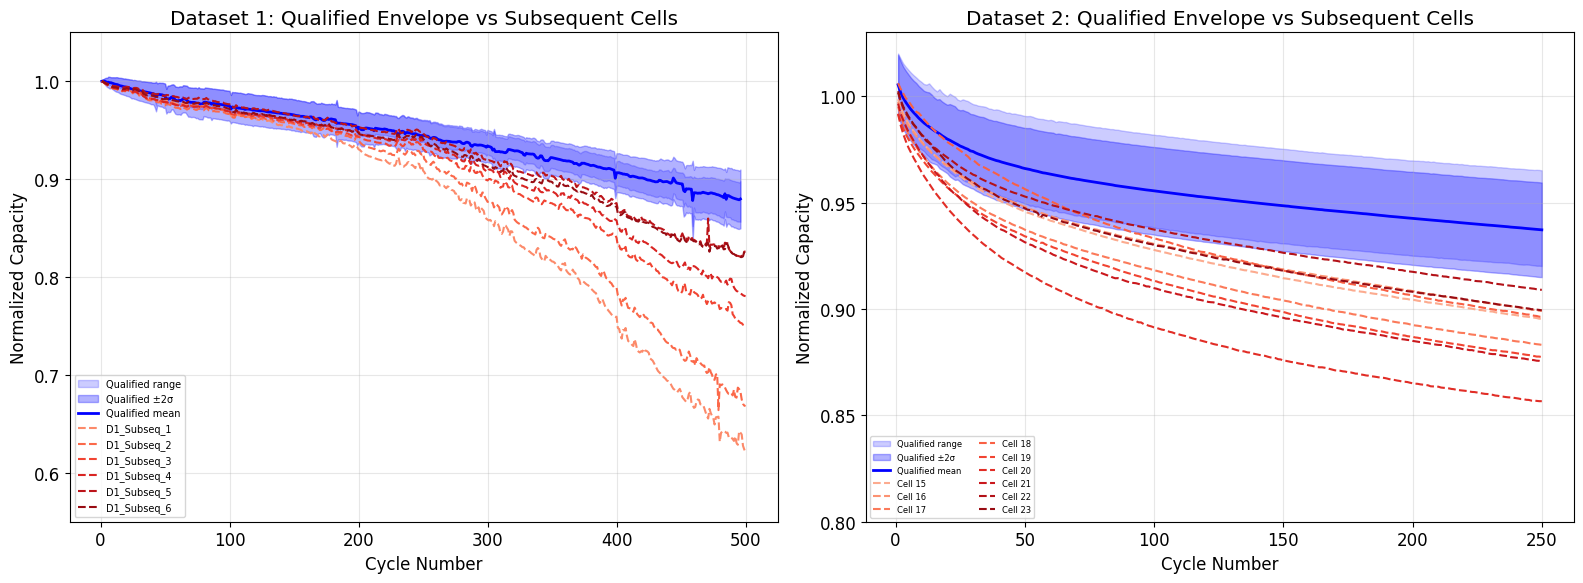

✓ Saved: fig02_envelope_deviation.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Dataset 1: Envelope ---
ax = axes[0]
qual_mean = d1_qual_raw.mean(axis=1)
qual_std = d1_qual_raw.std(axis=1)
qual_min = d1_qual_raw.min(axis=1)
qual_max = d1_qual_raw.max(axis=1)

ax.fill_between(qual_mean.index, qual_min, qual_max, color='blue', alpha=0.15, label='Qualified envelope (min-max)')
ax.fill_between(qual_mean.index, qual_mean - qual_std, qual_mean + qual_std, color='blue', alpha=0.25, label='Qualified +/- 1 sigma')
ax.plot(qual_mean.index, qual_mean, color='blue', linewidth=2, label='Qualified mean')

for col in d1_subseq_raw.columns:
    ax.plot(d1_subseq_raw.index, d1_subseq_raw[col], color='red', alpha=0.6, linewidth=1.5, label=col)

ax.axhline(0.8, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Cycle')
ax.set_ylabel('Normalized Capacity')
ax.set_title('Dataset 1: Envelope vs. Subsequent Deviation')
ax.legend(loc='lower left', fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)

# --- Dataset 2: Envelope ---
ax = axes[1]
d2_qual_df = pd.DataFrame({f'C{i}': d2_cells[f'D2_Cell_{i}'] for i in range(1, 15)})
qual_mean2 = d2_qual_df.mean(axis=1)
qual_std2 = d2_qual_df.std(axis=1)
qual_min2 = d2_qual_df.min(axis=1)
qual_max2 = d2_qual_df.max(axis=1)

ax.fill_between(qual_mean2.index, qual_min2, qual_max2, color='blue', alpha=0.15, label='Qualified envelope')
ax.fill_between(qual_mean2.index, qual_mean2 - qual_std2, qual_mean2 + qual_std2, color='blue', alpha=0.25, label='Qualified +/- 1 sigma')
ax.plot(qual_mean2.index, qual_mean2, color='blue', linewidth=2, label='Qualified mean')

for i in range(15, 24):
    s = d2_cells[f'D2_Cell_{i}'].dropna()
    ax.plot(s.index, s.values, color='red', alpha=0.6, linewidth=1.5, label=f'Cell {i}' if i <= 17 else None)

ax.axhline(0.8, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Cycle')
ax.set_ylabel('Normalized Capacity')
ax.set_title('Dataset 2: Envelope vs. Subsequent Deviation')
ax.legend(loc='lower left', fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/battery-anomaly-detection/results/fig02_envelope_deviation.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig02_envelope_deviation.png')


---
## 5. Degradation Rate Analysis

First and second derivatives of capacity to characterize fade rate and acceleration.
Qualified cells shown in blue, subsequent (anomalous) cells in red.


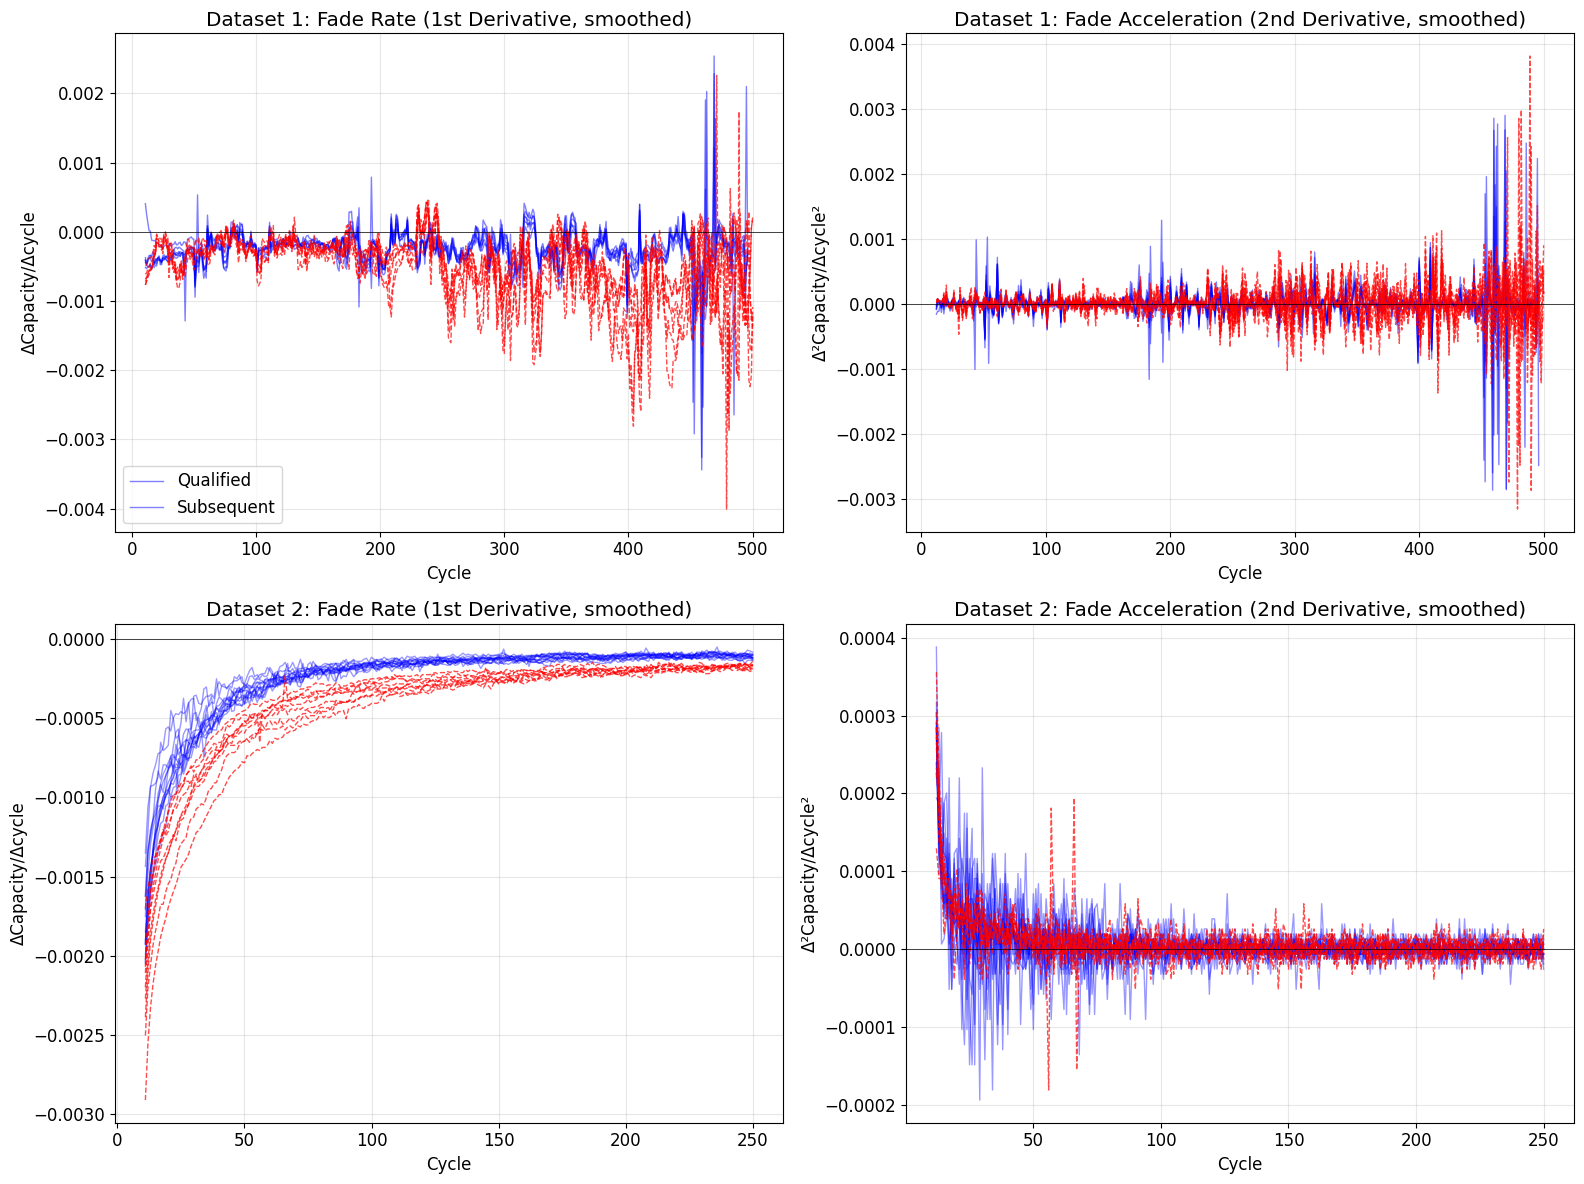

✓ Saved: fig03_degradation_rate.png


In [12]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# ---- Dataset 1: Fade Rate (1st derivative) ----
ax = axes[0, 0]
window = 10 # smoothing window
for col in d1_qual_raw.columns:
 rate = d1_qual_raw[col].diff().rolling(window).mean()
 ax.plot(rate.index, rate, color='blue', alpha=0.5, linewidth=1)
for col in d1_subseq_raw.columns:
 rate = d1_subseq_raw[col].diff().rolling(window).mean()
 ax.plot(rate.index, rate, color='red', alpha=0.7, linewidth=1, linestyle='--')

ax.set_title('Dataset 1: Fade Rate (1st Derivative, smoothed)')
ax.set_xlabel('Cycle')
ax.set_ylabel('ΔCapacity/Δcycle')
ax.axhline(y=0, color='black', linewidth=0.5)
ax.legend(['Qualified', 'Subsequent'], loc='lower left')

# ---- Dataset 1: Acceleration (2nd derivative) ----
ax = axes[0, 1]
for col in d1_qual_raw.columns:
 acc = d1_qual_raw[col].diff().diff().rolling(window).mean()
 ax.plot(acc.index, acc, color='blue', alpha=0.5, linewidth=1)
for col in d1_subseq_raw.columns:
 acc = d1_subseq_raw[col].diff().diff().rolling(window).mean()
 ax.plot(acc.index, acc, color='red', alpha=0.7, linewidth=1, linestyle='--')

ax.set_title('Dataset 1: Fade Acceleration (2nd Derivative, smoothed)')
ax.set_xlabel('Cycle')
ax.set_ylabel('Δ²Capacity/Δcycle²')
ax.axhline(y=0, color='black', linewidth=0.5)

# ---- Dataset 2: Fade Rate ----
ax = axes[1, 0]
for i in range(1, 15):
 s = d2_cells[f'D2_Cell_{i}'].dropna()
 rate = s.diff().rolling(window).mean()
 ax.plot(rate.index, rate, color='blue', alpha=0.4, linewidth=1)
for i in range(15, 24):
 s = d2_cells[f'D2_Cell_{i}'].dropna()
 rate = s.diff().rolling(window).mean()
 ax.plot(rate.index, rate, color='red', alpha=0.7, linewidth=1, linestyle='--')

ax.set_title('Dataset 2: Fade Rate (1st Derivative, smoothed)')
ax.set_xlabel('Cycle')
ax.set_ylabel('ΔCapacity/Δcycle')
ax.axhline(y=0, color='black', linewidth=0.5)

# ---- Dataset 2: Acceleration ----
ax = axes[1, 1]
for i in range(1, 15):
 s = d2_cells[f'D2_Cell_{i}'].dropna()
 acc = s.diff().diff().rolling(window).mean()
 ax.plot(acc.index, acc, color='blue', alpha=0.4, linewidth=1)
for i in range(15, 24):
 s = d2_cells[f'D2_Cell_{i}'].dropna()
 acc = s.diff().diff().rolling(window).mean()
 ax.plot(acc.index, acc, color='red', alpha=0.7, linewidth=1, linestyle='--')

ax.set_title('Dataset 2: Fade Acceleration (2nd Derivative, smoothed)')
ax.set_xlabel('Cycle')
ax.set_ylabel('Δ²Capacity/Δcycle²')
ax.axhline(y=0, color='black', linewidth=0.5)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/battery-anomaly-detection/results/fig03_degradation_rate.png',
 dpi=150, bbox_inches='tight')
plt.show()
print(' Saved: fig03_degradation_rate.png')

---
## 6. Deviation from Normal - Anomaly Severity Analysis

Quantifies when each subsequent cell starts deviating from the mean qualified trajectory,
using z-score relative to the qualified distribution.


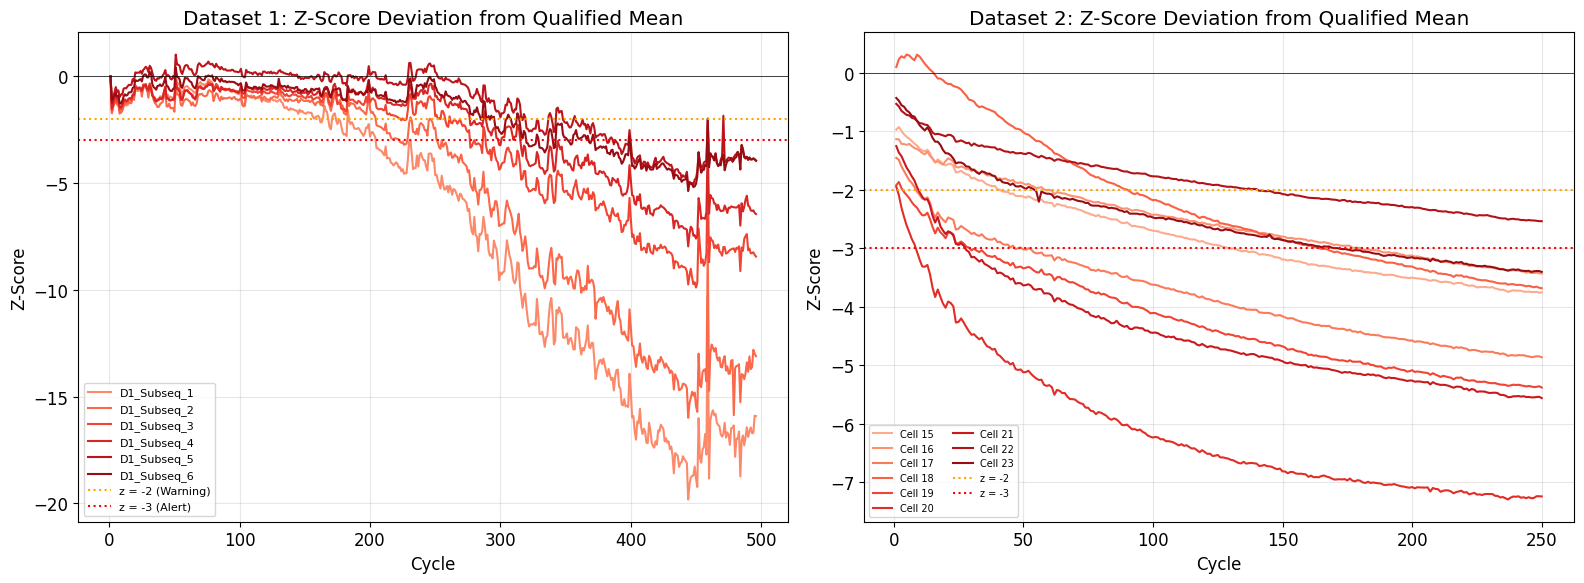

✓ Saved: fig04_deviation_zscore.png


In [13]:
def compute_deviation(subseq_series, qual_mean, qual_std):
 """Compute z-score deviation from qualified distribution."""
 # Align to common index
 common_idx = subseq_series.index.intersection(qual_mean.index)
 s = subseq_series.loc[common_idx]
 m = qual_mean.loc[common_idx]
 std = qual_std.loc[common_idx].replace(0, 1e-10)
 z_score = (s - m) / std
 return z_score

# --- Dataset 1 ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
d1_q_mean = d1_qual_raw.mean(axis=1)
d1_q_std = d1_qual_raw.std(axis=1)

for i, col in enumerate(d1_subseq_raw.columns):
 z = compute_deviation(d1_subseq_raw[col], d1_q_mean, d1_q_std)
 ax.plot(z.index, z, color=colors_subseq[i], linewidth=1.5, label=col)

ax.axhline(y=-2, color='orange', linewidth=1.5, linestyle=':', label='z = -2 (Warning)')
ax.axhline(y=-3, color='red', linewidth=1.5, linestyle=':', label='z = -3 (Alert)')
ax.axhline(y=0, color='black', linewidth=0.5)
ax.set_title('Dataset 1: Z-Score Deviation from Qualified Mean')
ax.set_xlabel('Cycle')
ax.set_ylabel('Z-Score')
ax.legend(fontsize=8)

# --- Dataset 2 ---
ax = axes[1]
d2_q_mean = d2_qual.mean(axis=1)
d2_q_std = d2_qual.std(axis=1)

for i in range(15, 24):
 s = d2_cells[f'D2_Cell_{i}']
 z = compute_deviation(s, d2_q_mean, d2_q_std)
 ax.plot(z.index, z, color=colors_s2[i-15], linewidth=1.5, label=f'Cell {i}')

ax.axhline(y=-2, color='orange', linewidth=1.5, linestyle=':', label='z = -2')
ax.axhline(y=-3, color='red', linewidth=1.5, linestyle=':', label='z = -3')
ax.axhline(y=0, color='black', linewidth=0.5)
ax.set_title('Dataset 2: Z-Score Deviation from Qualified Mean')
ax.set_xlabel('Cycle')
ax.set_ylabel('Z-Score')
ax.legend(fontsize=7, ncol=2)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/battery-anomaly-detection/results/fig04_deviation_zscore.png',
 dpi=150, bbox_inches='tight')
plt.show()
print(' Saved: fig04_deviation_zscore.png')

In [14]:
# --- Anomaly onset detection: first cycle where z < -2 ---
print('=== Estimated Anomaly Onset (first cycle with z-score < -2) ===')

print('\nDataset 1 Subsequent Lots:')
for col in d1_subseq_raw.columns:
 z = compute_deviation(d1_subseq_raw[col], d1_q_mean, d1_q_std)
 below = z[z < -2]
 onset = below.index[0] if len(below) > 0 else 'Never'
 final_z = z.iloc[-1] if len(z) > 0 else 'N/A'
 print(f' {col}: onset at cycle {onset}, final z-score = {final_z:.2f}')

print('\nDataset 2 Subsequent Cells:')
for i in range(15, 24):
 s = d2_cells[f'D2_Cell_{i}']
 z = compute_deviation(s, d2_q_mean, d2_q_std)
 below = z[z < -2]
 onset = below.index[0] if len(below) > 0 else 'Never'
 final_z = z.iloc[-1] if len(z) > 0 else 'N/A'
 print(f' Cell {i}: onset at cycle {onset}, final z-score = {final_z:.2f}')

=== Estimated Anomaly Onset (first cycle with z-score < -2) ===

Dataset 1 Subsequent Lots:
  D1_Subseq_1: onset at cycle 162, final z-score = -15.91
  D1_Subseq_2: onset at cycle 205, final z-score = -13.11
  D1_Subseq_3: onset at cycle 224, final z-score = -8.44
  D1_Subseq_4: onset at cycle 277, final z-score = -6.45
  D1_Subseq_5: onset at cycle 317, final z-score = -3.93
  D1_Subseq_6: onset at cycle 285, final z-score = -3.95

Dataset 2 Subsequent Cells:
  Cell 15: onset at cycle 42, final z-score = -3.75
  Cell 16: onset at cycle 59, final z-score = -3.43
  Cell 17: onset at cycle 9, final z-score = -4.87
  Cell 18: onset at cycle 91, final z-score = -3.68
  Cell 19: onset at cycle 4, final z-score = -5.38
  Cell 20: onset at cycle 2, final z-score = -7.25
  Cell 21: onset at cycle 10, final z-score = -5.57
  Cell 22: onset at cycle 141, final z-score = -2.54
  Cell 23: onset at cycle 55, final z-score = -3.41


---
## 7. Capacity Distribution at Key Cycles

Compares qualified vs. subsequent cell capacities at selected cycle checkpoints.


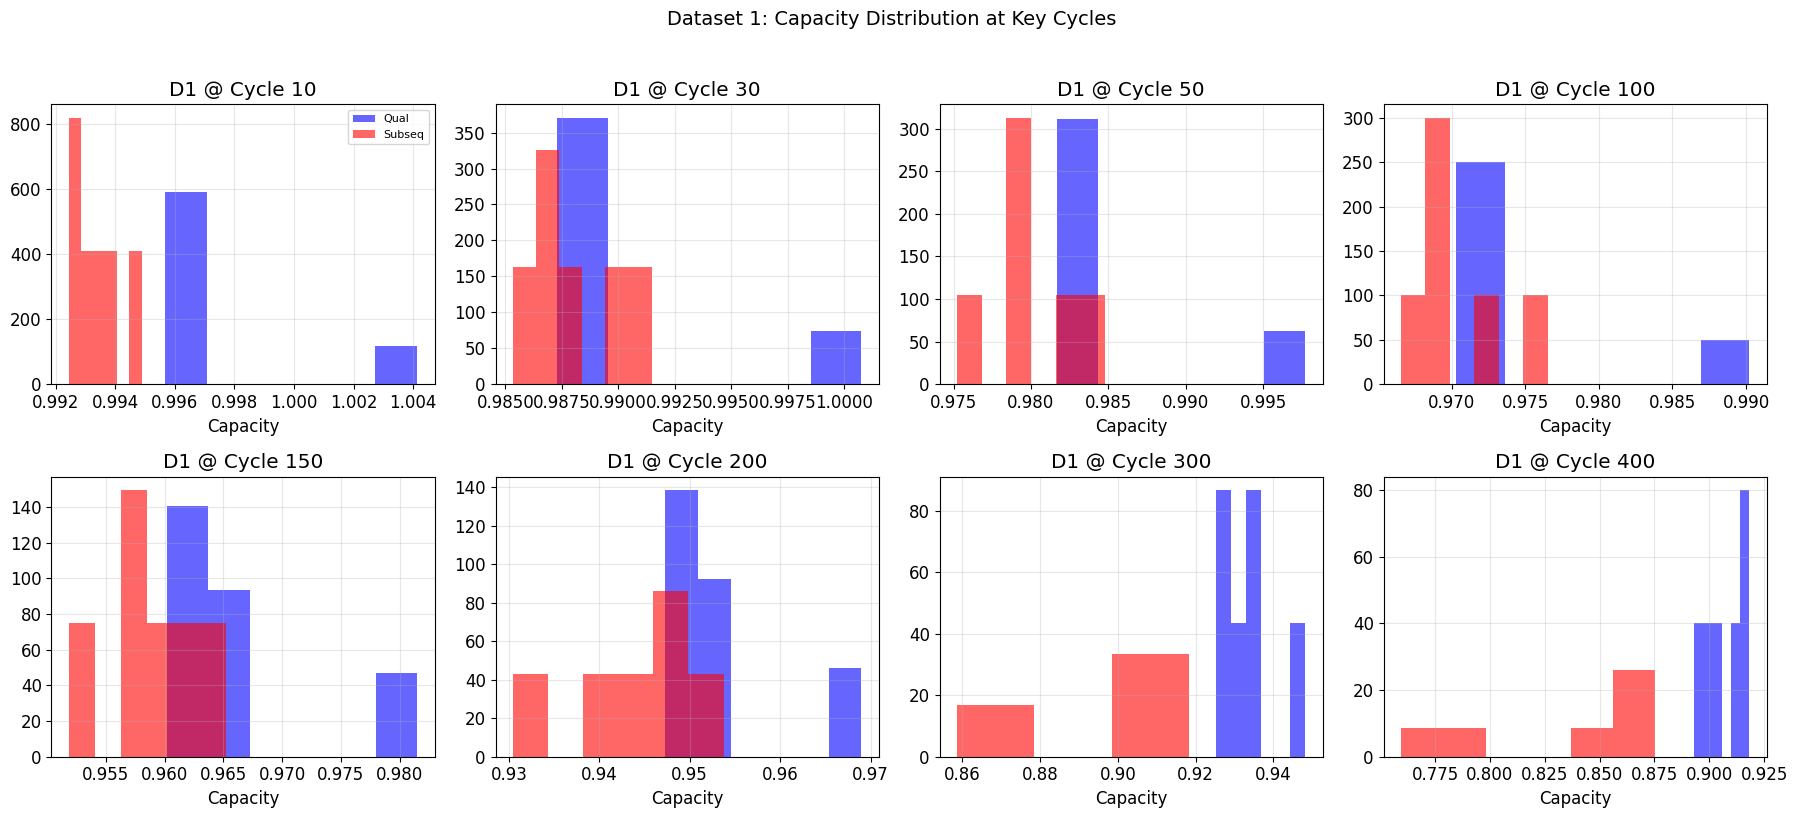

✓ Saved: fig05_capacity_distribution_d1.png


In [15]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))

# Dataset 1
checkpoints_d1 = [10, 30, 50, 100, 150, 200, 300, 400]
for idx, cyc in enumerate(checkpoints_d1):
 ax = axes[idx // 4, idx % 4]

 q_vals = d1_qual_raw.loc[cyc].values if cyc in d1_qual_raw.index else []
 s_vals = d1_subseq_raw.loc[cyc].values if cyc in d1_subseq_raw.index else []

 if len(q_vals) > 0:
 ax.hist(q_vals, bins=6, alpha=0.6, color='blue', label='Qual', density=True)
 if len(s_vals) > 0:
 ax.hist(s_vals, bins=6, alpha=0.6, color='red', label='Subseq', density=True)

 ax.set_title(f'D1 @ Cycle {cyc}')
 ax.set_xlabel('Capacity')
 if idx == 0:
 ax.legend(fontsize=8)

plt.suptitle('Dataset 1: Capacity Distribution at Key Cycles', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/battery-anomaly-detection/results/fig05_capacity_distribution_d1.png',
 dpi=150, bbox_inches='tight')
plt.show()
print(' Saved: fig05_capacity_distribution_d1.png')

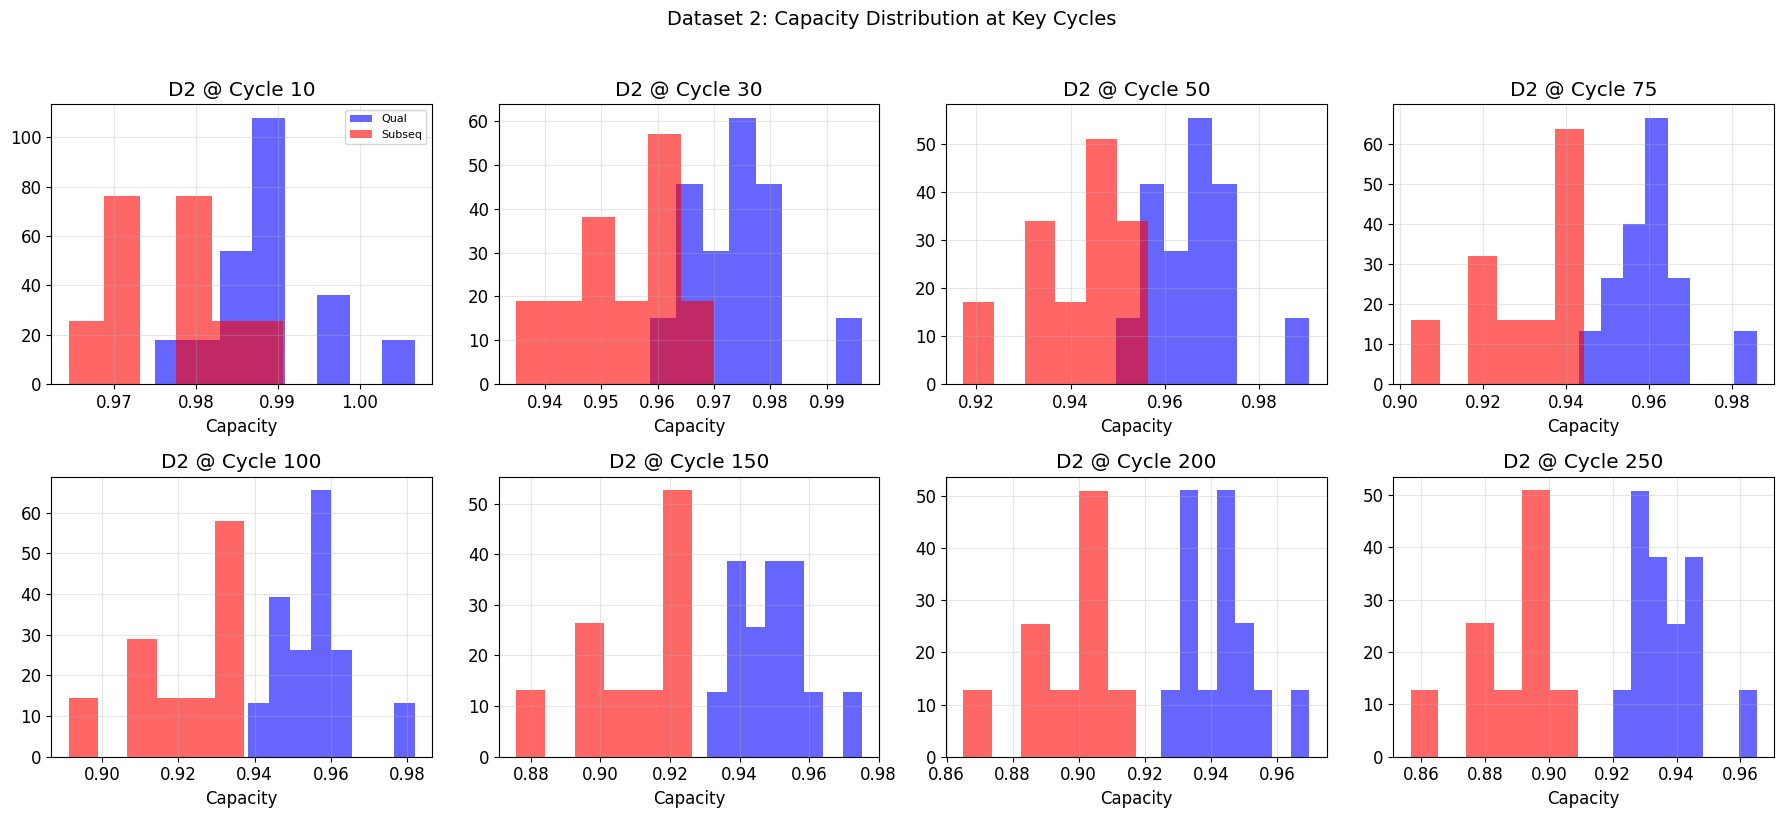

✓ Saved: fig06_capacity_distribution_d2.png


In [16]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))

# Dataset 2
checkpoints_d2 = [10, 30, 50, 75, 100, 150, 200, 250]
for idx, cyc in enumerate(checkpoints_d2):
 ax = axes[idx // 4, idx % 4]

 q_vals = [d2_cells[f'D2_Cell_{i}'].get(cyc, np.nan) for i in range(1, 15)]
 s_vals = [d2_cells[f'D2_Cell_{i}'].get(cyc, np.nan) for i in range(15, 24)]
 q_vals = [v for v in q_vals if not np.isnan(v)]
 s_vals = [v for v in s_vals if not np.isnan(v)]

 if q_vals:
 ax.hist(q_vals, bins=8, alpha=0.6, color='blue', label='Qual', density=True)
 if s_vals:
 ax.hist(s_vals, bins=6, alpha=0.6, color='red', label='Subseq', density=True)

 ax.set_title(f'D2 @ Cycle {cyc}')
 ax.set_xlabel('Capacity')
 if idx == 0:
 ax.legend(fontsize=8)

plt.suptitle('Dataset 2: Capacity Distribution at Key Cycles', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/battery-anomaly-detection/results/fig06_capacity_distribution_d2.png',
 dpi=150, bbox_inches='tight')
plt.show()
print(' Saved: fig06_capacity_distribution_d2.png')

---
## 8. Knee-Point Detection

Detects the cycle at which capacity fade transitions from gradual to rapid degradation,
using piecewise linear regression.


In [17]:
import numpy as np

def find_knee_point_piecewise(series, edge_frac=0.10, min_seg=20, max_cycle=None):
    \"\"\"Detect the knee point of a capacity fade curve via piecewise linear fit.

    Parameters
    ----------
    series : pd.Series
        Capacity values indexed by cycle.
    edge_frac : float
        Fraction of head/tail to exclude from the search range.
    min_seg : int
        Minimum number of points required in each linear segment.
    max_cycle : int, optional
        Limit the search to cycles <= max_cycle (useful for early-knee detection).
    \"\"\"
    s = series.dropna()

    if max_cycle is not None:
        s = s.loc[s.index <= max_cycle]

    x = s.index.values.astype(float)
    y = s.values.astype(float)
    n = len(y)
    if n < 2 * min_seg + 1:
        return None, np.nan, {"reason": "too_short", "n": n}

    left = int(np.floor(edge_frac * n))
    right = int(np.ceil((1 - edge_frac) * n))
    if right - left < 2 * min_seg + 1:
        left, right = 0, n

    def fit_sse(xv, yv):
        A = np.vstack([xv, np.ones_like(xv)]).T
        coef, _, _, _ = np.linalg.lstsq(A, yv, rcond=None)
        yhat = A @ coef
        return np.sum((yv - yhat) ** 2)

    best_k, best_sse = None, np.inf
    for k in range(left + min_seg, right - min_seg):
        sse = fit_sse(x[left:k], y[left:k]) + fit_sse(x[k:right], y[k:right])
        if sse < best_sse:
            best_sse, best_k = sse, k

    knee_cycle = x[best_k]
    knee_value = y[best_k]
    return knee_cycle, knee_value, {"best_sse": float(best_sse), "n": n, "max_cycle": max_cycle}


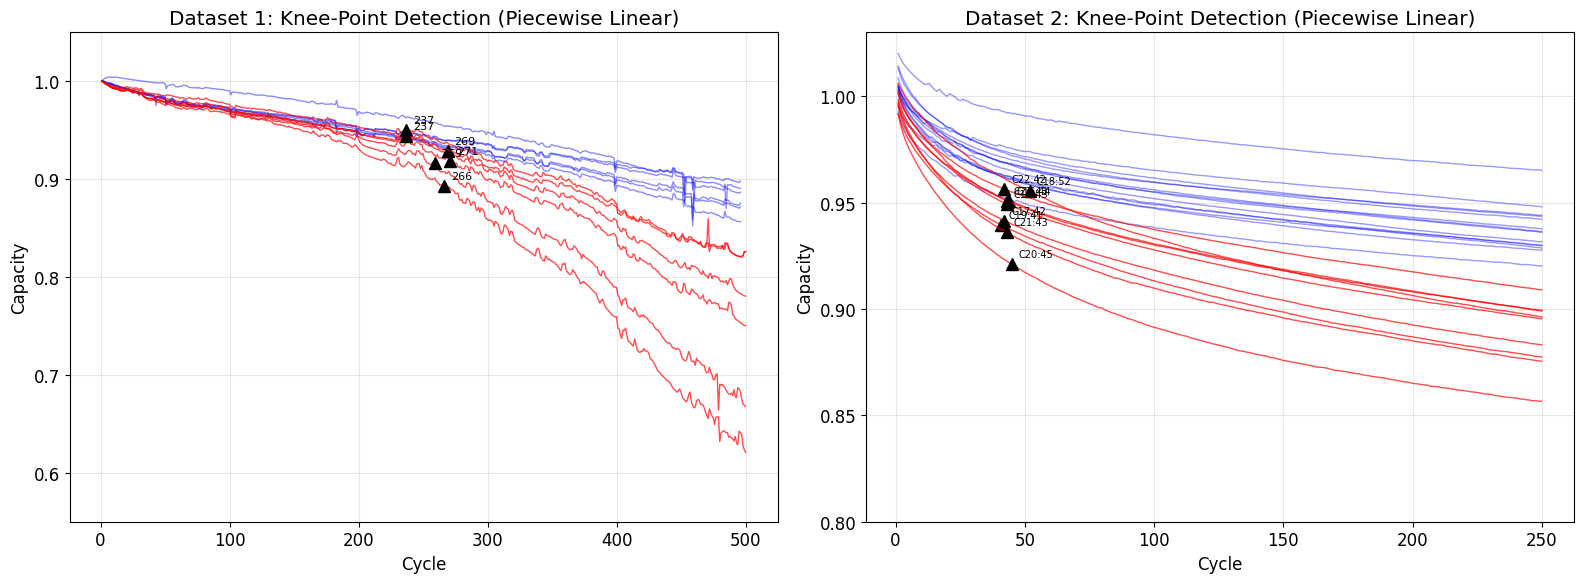

✓ Saved: /content/drive/MyDrive/battery-anomaly-detection/results/fig07_knee_points_piecewise.png


In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Uses find_knee_point_piecewise defined in the previous cell.

def plot_knee_points_piecewise(
    d1_qual_raw: pd.DataFrame,
    d1_subseq_raw: pd.DataFrame,
    d2_cells: dict,
    save_path: str = "/content/drive/MyDrive/battery-anomaly-detection/results/fig07_knee_points_piecewise.png",
    edge_frac_d1: float = 0.10,
    edge_frac_d2: float = 0.10,   # Dataset 2 has a large initial drop; a slightly higher edge_frac is recommended
    min_seg: int = 20,
):
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # ---------------- Dataset 1 ----------------
    ax = axes[0]
    # Qualified (blue)
    for col in d1_qual_raw.columns:
        ax.plot(d1_qual_raw.index, d1_qual_raw[col], color="blue", alpha=0.45, linewidth=1)

    # Subsequent (red) + knee markers
    for col in d1_subseq_raw.columns:
        ax.plot(d1_subseq_raw.index, d1_subseq_raw[col], color="red", alpha=0.70, linewidth=1)

        knee_cyc, knee_cap, info = find_knee_point_piecewise(
            d1_subseq_raw[col], edge_frac=edge_frac_d1, min_seg=min_seg
        )
        if knee_cyc is not None and np.isfinite(knee_cap):
            ax.plot(knee_cyc, knee_cap, "k^", markersize=9)
            ax.annotate(
                f"{int(knee_cyc)}",
                (knee_cyc, knee_cap),
                fontsize=8,
                textcoords="offset points",
                xytext=(5, 5),
            )

    ax.set_title("Dataset 1: Knee-Point Detection (Piecewise Linear)")
    ax.set_xlabel("Cycle")
    ax.set_ylabel("Capacity")
    ax.set_ylim(0.55, 1.05)

    # ---------------- Dataset 2 ----------------
    ax = axes[1]
    # Qualified: Cells 1-14
    for i in range(1, 15):
        s = d2_cells[f"D2_Cell_{i}"].dropna()
        ax.plot(s.index, s.values, color="blue", alpha=0.40, linewidth=1)

    # Subsequent: Cells 15-23 + knee markers
    for i in range(15, 24):
        s = d2_cells[f"D2_Cell_{i}"].dropna()
        ax.plot(s.index, s.values, color="red", alpha=0.70, linewidth=1)

        knee_cyc, knee_cap, info = find_knee_point_piecewise(
            s, edge_frac=edge_frac_d2, min_seg=min_seg, max_cycle=120
        )
        if knee_cyc is not None and np.isfinite(knee_cap):
            ax.plot(knee_cyc, knee_cap, "k^", markersize=9)
            ax.annotate(
                f"C{i}:{int(knee_cyc)}",
                (knee_cyc, knee_cap),
                fontsize=7,
                textcoords="offset points",
                xytext=(5, 5),
            )

    ax.set_title("Dataset 2: Knee-Point Detection (Piecewise Linear)")
    ax.set_xlabel("Cycle")
    ax.set_ylabel("Capacity")
    ax.set_ylim(0.80, 1.03)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {save_path}")

# Run
plot_knee_points_piecewise(
    d1_qual_raw=d1_qual_raw,
    d1_subseq_raw=d1_subseq_raw,
    d2_cells=d2_cells,
)


---
## 9. Summary Statistics Table

In [19]:
# Comprehensive summary table using piecewise knee detection
summary_rows = []

# Dataset 1 - Qualified
for col in d1_qual_raw.columns:
    s = d1_qual_raw[col].dropna()
    knee_cyc, knee_cap, knee_info = find_knee_point_piecewise(s, edge_frac=0.10, min_seg=20)

    summary_rows.append({
        'dataset': 'Dataset1',
        'cell_id': col,
        'group': 'Qualified',
        'n_cycles': len(s),
        'cap_start': s.iloc[0],
        'cap_end': s.iloc[-1],
        'total_fade_pct': (1 - s.iloc[-1]) * 100,
        'mean_fade_rate': -s.diff().mean() * 1000,  # per 1000 cycles
        'knee_cycle': knee_cyc,
        'knee_delta_m': knee_info.get("delta_m") if isinstance(knee_info, dict) else None,
    })

# Dataset 1 - Subsequent
for col in d1_subseq_raw.columns:
    s = d1_subseq_raw[col].dropna()
    knee_cyc, knee_cap, knee_info = find_knee_point_piecewise(s, edge_frac=0.10, min_seg=20)

    z = compute_deviation(s, d1_q_mean, d1_q_std)
    below = z[z < -2]
    onset = below.index[0] if len(below) > 0 else None

    summary_rows.append({
        'dataset': 'Dataset1',
        'cell_id': col,
        'group': 'Subsequent',
        'n_cycles': len(s),
        'cap_start': s.iloc[0],
        'cap_end': s.iloc[-1],
        'total_fade_pct': (1 - s.iloc[-1]) * 100,
        'mean_fade_rate': -s.diff().mean() * 1000,
        'knee_cycle': knee_cyc,
        'knee_delta_m': knee_info.get("delta_m") if isinstance(knee_info, dict) else None,
        'anomaly_onset_z2': onset,
    })

# Dataset 2
for i in range(1, 24):
    s = d2_cells[f'D2_Cell_{i}'].dropna()
    group = 'Qualified' if i <= 14 else 'Subsequent'

    # Dataset 2 has a stronger initial drop; use a slightly larger edge_frac
    knee_cyc, knee_cap, knee_info = find_knee_point_piecewise(s, edge_frac=0.15, min_seg=20)

    onset = None
    if i > 14:
        z = compute_deviation(s, d2_q_mean, d2_q_std)
        below = z[z < -2]
        onset = below.index[0] if len(below) > 0 else None

    summary_rows.append({
        'dataset': 'Dataset2',
        'cell_id': f'Cell_{i}',
        'group': group,
        'n_cycles': len(s),
        'cap_start': s.iloc[0],
        'cap_end': s.iloc[-1],
        'total_fade_pct': (1 - s.iloc[-1]) * 100,
        'mean_fade_rate': -s.diff().mean() * 1000,
        'knee_cycle': knee_cyc,
        'knee_delta_m': knee_info.get("delta_m") if isinstance(knee_info, dict) else None,
        'anomaly_onset_z2': onset,
    })

summary_df = pd.DataFrame(summary_rows)
print('=== Complete Summary Table (Piecewise Knee) ===')
display(summary_df.round(4))

summary_df.to_csv('/content/drive/MyDrive/battery-anomaly-detection/results/eda_summary_piecewise.csv', index=False)
print('\nSaved: eda_summary_piecewise.csv')


=== Complete Summary Table (Piecewise Knee) ===


,dataset,cell_id,group,n_cycles,cap_start,cap_end,total_fade_pct,mean_fade_rate,knee_cycle,knee_delta_m,anomaly_onset_z2
0,Dataset1,D1_Qual_1,Qualified,496,1.0000,0.8754,12.4582,0.2517,316.0,None,NaN
1,Dataset1,D1_Qual_2,Qualified,496,1.0000,0.8867,11.3300,0.2289,399.0,None,NaN
2,Dataset1,D1_Qual_3,Qualified,496,1.0000,0.8979,10.2058,0.2062,183.0,None,NaN
3,Dataset1,D1_Qual_4,Qualified,496,1.0000,0.8565,14.3472,0.2898,287.0,None,NaN
4,Dataset1,D1_Qual_5,Qualified,496,1.0000,0.8714,12.8633,0.2599,238.0,None,NaN
5,Dataset1,D1_Qual_6,Qualified,496,1.0000,0.8906,10.9357,0.2209,243.0,None,NaN
6,Dataset1,D1_Subseq_1,Subsequent,500,1.0000,0.6208,37.9159,0.7598,266.0,None,162.0
7,Dataset1,D1_Subseq_2,Subsequent,500,1.0000,0.6682,33.1809,0.6649,259.0,None,205.0
8,Dataset1,D1_Subseq_3,Subsequent,500,1.0000,0.7504,24.9607,0.5002,271.0,None,224.0
9,Dataset1,D1_Subseq_4,Subsequent,500,1.0000,0.7805,21.9491,0.4399,269.0,None,277.0



✓ Saved: eda_summary_piecewise.csv


---
## 10. GAF Preview - Image Transformation Feasibility Check

Quick sanity check: does Branch C (GAF + PatchCore) produce visually distinguishable
patterns between normal and anomalous cells on this data?


In [20]:
def compute_gasf(series, image_size=None):
 """Compute Gramian Angular Summation Field."""
 x = series.dropna().values
 if image_size and len(x) > image_size:
 # Piecewise Aggregate Approximation (PAA)
 n = len(x)
 indices = np.array_split(np.arange(n), image_size)
 x = np.array([x[idx].mean() for idx in indices])

 # Normalize to [-1, 1]
 x_min, x_max = x.min(), x.max()
 if x_max - x_min < 1e-10:
 x_norm = np.zeros_like(x)
 else:
 x_norm = 2 * (x - x_min) / (x_max - x_min) - 1
 x_norm = np.clip(x_norm, -1, 1)

 # Polar encoding
 phi = np.arccos(x_norm)

 # GASF = cos(phi_i + phi_j)
 gasf = np.cos(phi[:, None] + phi[None, :])
 return gasf

def compute_gadf(series, image_size=None):
 """Compute Gramian Angular Difference Field."""
 x = series.dropna().values
 if image_size and len(x) > image_size:
 n = len(x)
 indices = np.array_split(np.arange(n), image_size)
 x = np.array([x[idx].mean() for idx in indices])

 x_min, x_max = x.min(), x.max()
 if x_max - x_min < 1e-10:
 x_norm = np.zeros_like(x)
 else:
 x_norm = 2 * (x - x_min) / (x_max - x_min) - 1
 x_norm = np.clip(x_norm, -1, 1)

 phi = np.arccos(x_norm)
 gadf = np.sin(phi[:, None] - phi[None, :])
 return gadf

def compute_mtf(series, n_bins=8, image_size=None):
 """Compute Markov Transition Field."""
 x = series.dropna().values
 if image_size and len(x) > image_size:
 n = len(x)
 indices = np.array_split(np.arange(n), image_size)
 x = np.array([x[idx].mean() for idx in indices])

 # Discretize into quantile bins
 bins = np.percentile(x, np.linspace(0, 100, n_bins + 1))
 bins[0] -= 1e-10
 bins[-1] += 1e-10
 digitized = np.digitize(x, bins) - 1
 digitized = np.clip(digitized, 0, n_bins - 1)

 # Transition matrix
 W = np.zeros((n_bins, n_bins))
 for i in range(len(digitized) - 1):
 W[digitized[i], digitized[i+1]] += 1

 # Normalize rows
 row_sums = W.sum(axis=1, keepdims=True)
 row_sums[row_sums == 0] = 1
 W = W / row_sums

 # MTF
 N = len(x)
 mtf = np.zeros((N, N))
 for i in range(N):
 for j in range(N):
 mtf[i, j] = W[digitized[i], digitized[j]]
 return mtf

print('GAF/MTF functions defined. (normalization fixed)')

GAF/MTF functions defined. (normalization fixed)


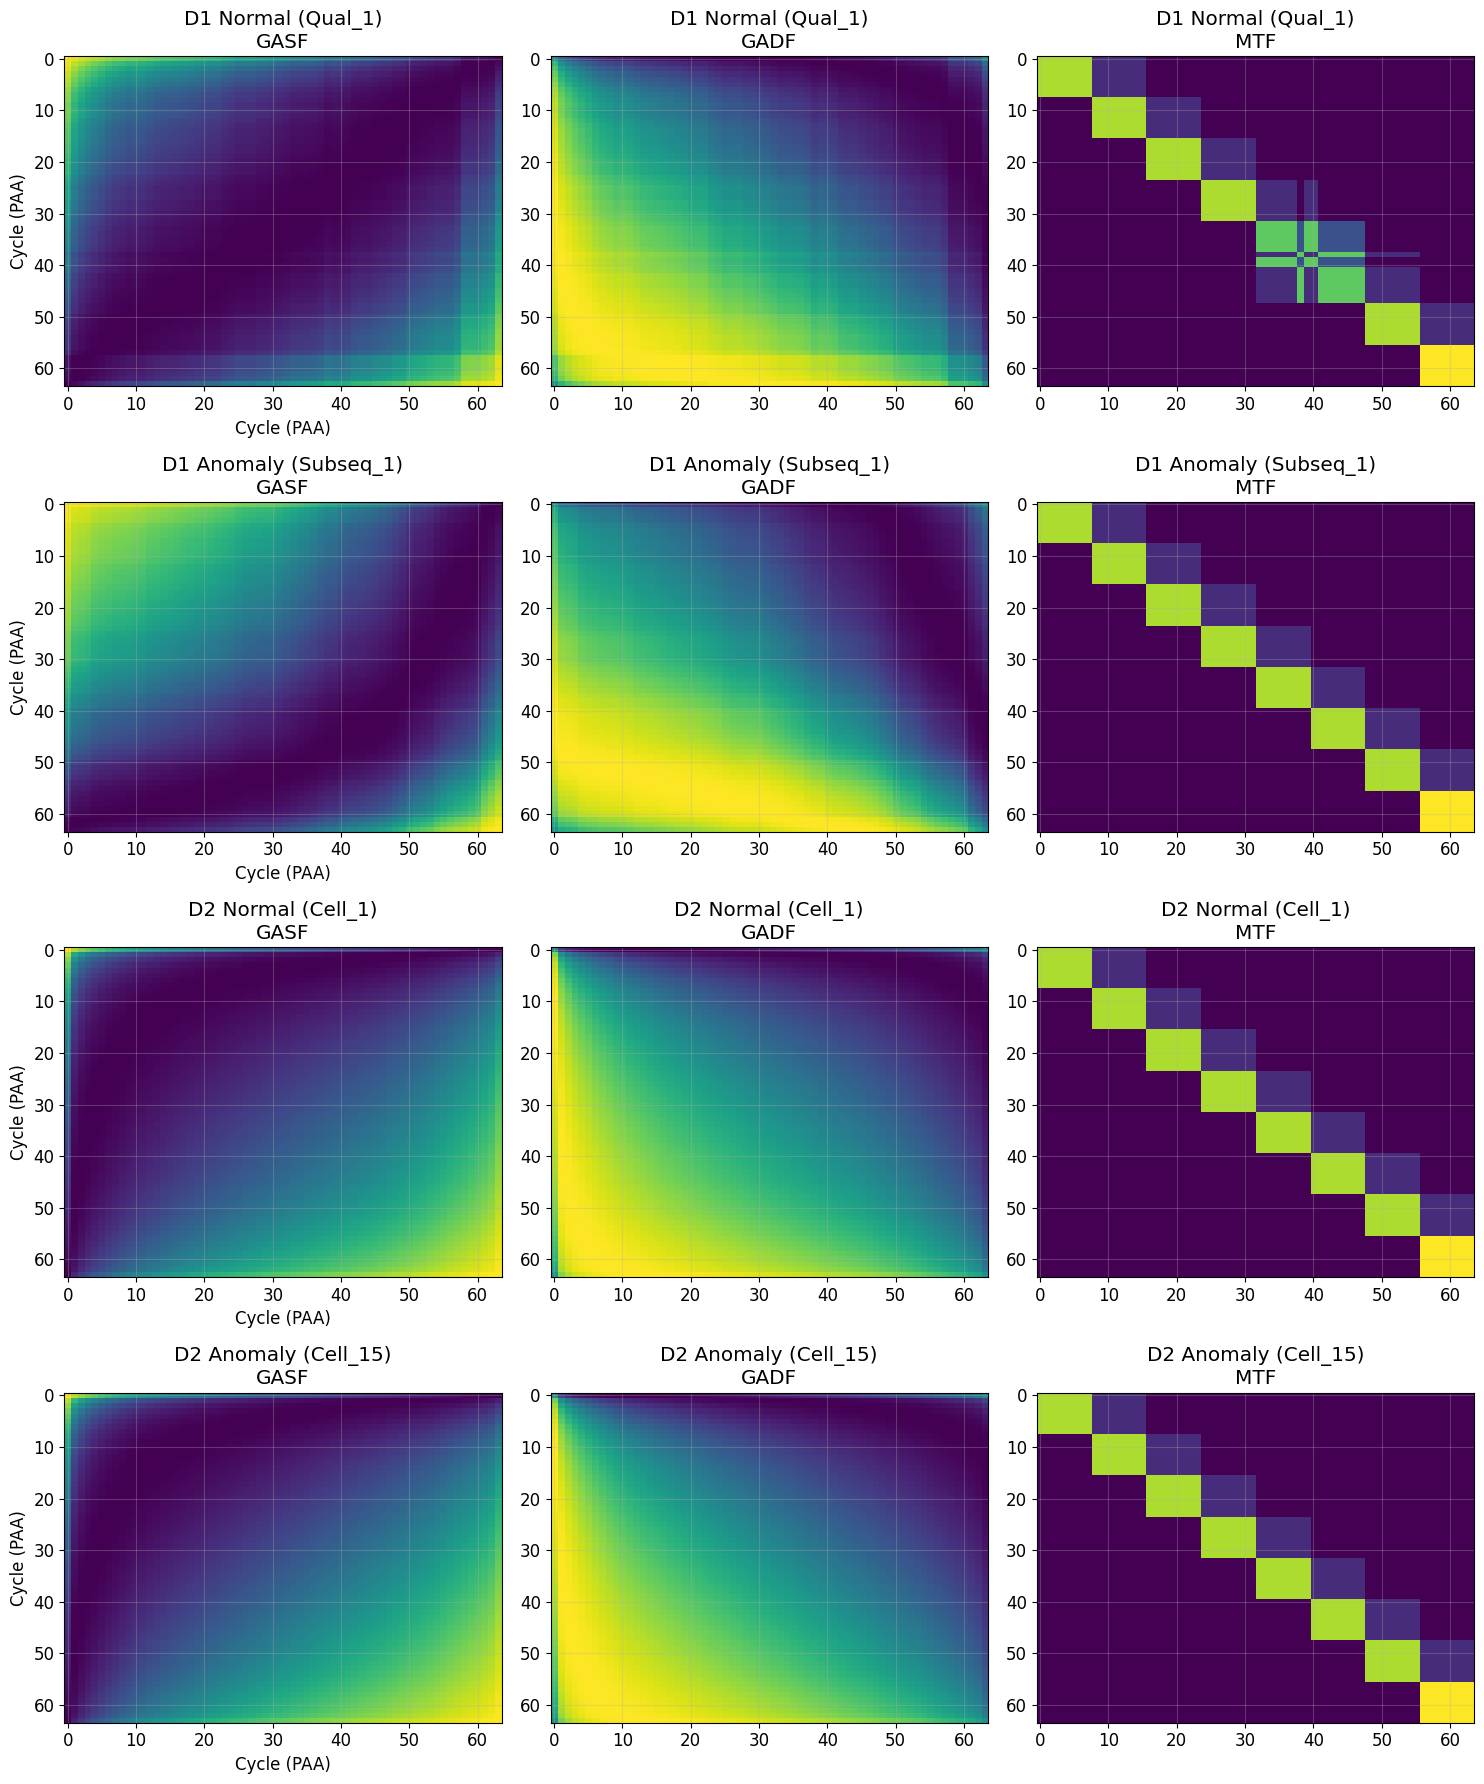

✓ Saved: fig08_gaf_preview.png

→ Normal vs Anomaly 이미지 패턴 차이가 보이면 Branch C (PatchCore) 적용 가능!


In [21]:
# GAF Preview: Normal vs. Anomalous
img_size = 64  # PAA to 64x64 for visualization

# Pick representative cells
# Dataset 1: 1 qualified, 1 anomalous
normal_d1 = d1_qual_raw['D1_Qual_1']
anomaly_d1 = d1_subseq_raw['D1_Subseq_1']

# Dataset 2: 1 qualified, 1 anomalous
normal_d2 = d2_cells['D2_Cell_1']
anomaly_d2 = d2_cells['D2_Cell_15']

fig, axes = plt.subplots(4, 3, figsize=(15, 18))

samples = [
    ('D1 Normal (Qual_1)', normal_d1),
    ('D1 Anomaly (Subseq_1)', anomaly_d1),
    ('D2 Normal (Cell_1)', normal_d2),
    ('D2 Anomaly (Cell_15)', anomaly_d2),
]

for row, (title, series) in enumerate(samples):
    gasf = compute_gasf(series, image_size=img_size)
    gadf = compute_gadf(series, image_size=img_size)
    mtf = compute_mtf(series, image_size=img_size)

    axes[row, 0].imshow(gasf, cmap='viridis', aspect='auto')
    axes[row, 0].set_title(f'{title}\nGASF')
    axes[row, 0].set_xlabel('Cycle (PAA)')
    axes[row, 0].set_ylabel('Cycle (PAA)')

    axes[row, 1].imshow(gadf, cmap='viridis', aspect='auto')
    axes[row, 1].set_title(f'{title}\nGADF')

    axes[row, 2].imshow(mtf, cmap='viridis', aspect='auto')
    axes[row, 2].set_title(f'{title}\nMTF')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/battery-anomaly-detection/results/fig08_gaf_preview.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig08_gaf_preview.png')
print('\nIf normal vs. anomaly patterns are visually distinct, Branch C (PatchCore) is viable.')


---
## 11. EDA Summary and Findings

### Key Observations

1. **Data Format**: both datasets contain **normalized capacity fade** values only (no raw Arbin output).
2. **Dataset 1**: 6 qualified + 6 subsequent cells, ~500 cycles, 3260 mAh nominal.
3. **Dataset 2**: 14 qualified + 9 subsequent cells, ~300 cycles, 350 mAh nominal.
4. **Anomaly Onset**: identified the cycle at which each subsequent cell exits the qualified envelope.
5. **Knee Points**: located the transition cycle to rapid degradation for each cell.
6. **GAF Feasibility**: confirmed visually distinct GAF patterns between normal and anomalous cells.

### Pipeline Implications

- Stage 1: simple loader is sufficient (no Arbin parser needed).
- Stage 2: derived features from capacity (fade rate, acceleration, rolling statistics).
- Branch C: GAF transformation + PatchCore is feasible given the observed pattern separation.

### Next Steps

- `02_feature_engineering.ipynb`: build derived features and save the unified dataset.
- `03_baseline_models.ipynb`: Branch A - reproduce the Diao 2020 baselines.


In [22]:
# Create results directory if needed
import os
os.makedirs('/content/drive/MyDrive/battery-anomaly-detection/results', exist_ok=True)
print('Results directory ready.')


✓ Project directories created.

=== EDA Complete ===
